CosmoComputationError: 

Error in Class: background_init(L:934) :error in background_solve(ppr,pba);
=>background_solve(L:2082) :error in generic_evolver(background_derivs, loga_ini, loga_final, pvecback_integration, used_in_output, pba->bi_size, &bpaw, ppr->tol_background_integration, ppr->smallest_allowed_variation, background_timescale, ppr->background_integration_stepsize, pba->loga_table, pba->bt_size, background_sources, ((void *)0), pba->error_message);
=>evolver_ndf15(L:499) :condition (absh <= hmin) is true; Step size too small: step:5.15779e-14, minimum:5.15779e-14, in interval: [-32.2362:0]


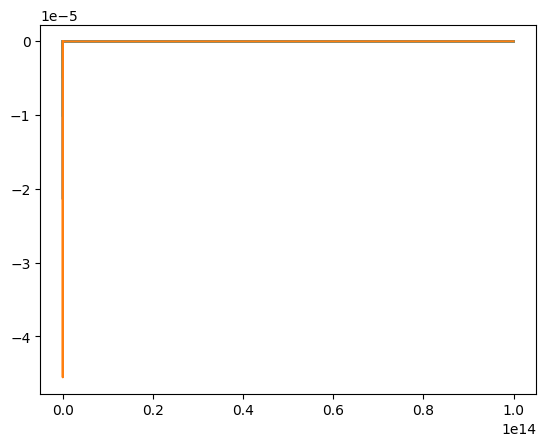

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from classy import Class

z_c     = 16.0
sigma_z = 3.25
H0      = 69
B       = -10

Omega_x = -np.logspace(-6, -2, num=13)

gaussian = np.exp(z_c**2 / (2 * sigma_z**2))

A_list = Omega_x * gaussian

latex_map = {
    '(.)rho_exo': r'\rho_{exo}',
    '(.)p_exo':   r'p_{exo}',
    'w_exo':      r'\omega_{exo}'}

target = '(.)rho_exo' # switch between (.)rho_exo, (.)p_exo, w_exo

for a_exo in A_list:
    model = Class()
    
    model.set({
        'z_c_exo':     z_c,  
        'sigma_z_exo': sigma_z,
        'H0':          H0,
        'b_exo':       B,
        'a_exo':       a_exo,
    })
    model.compute()

    data    = model.get_background()
#     print(data.keys())
    z       = data['z']
    
    plotting_data = data[target]
    
    plt.plot( z, plotting_data, label=f'$a_{{exo}}$={a_exo:.2e}, $\Omega_x = {a_exo / gaussian}$')
    
    model.struct_cleanup()
    model.empty()

xmax = 40
plt.xlim(0, xmax)
plt.yscale('symlog')
plt.xticks(np.arange(0, xmax, xmax/10))
plt.axvline(x= z_c, color='r', linestyle='--', alpha=0.5, label=f'$z_c$ = {z_c}')
plt.legend()

plt.xlabel('$\mathcal{z}$')

latex_label = latex_map.get(target, target)

plt.ylabel(f'${latex_label}$')
plt.savefig('plot_fixed.png', dpi=300)
plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from classy import Class

# --- Constants ---
c_km_s = 299792.458  # Speed of light to convert 1/Mpc to km/s/Mpc

# --- Setup ---
z_c     = 16.0
sigma_z = 3.25
H0      = 69.0
B       = -10.0
xmax    = 40

# Exotic amplitude calculations
Omega_x_vals = -np.logspace(-6, -2, num=13)

gaussian_factor = np.exp(z_c**2 / (2 * sigma_z**2))
A_list = Omega_x_vals * gaussian_factor

plt.figure(figsize=(10, 6))

# 1. Plot a Reference LCDM (No exotic DE)
lcdm = Class()
lcdm.set({'H0': H0, 'output': 'mPk'})
lcdm.compute()
bg_lcdm = lcdm.get_background()
plt.plot(bg_lcdm['z'], bg_lcdm['H [1/Mpc]'] * c_km_s, 
         'k--', lw=2, label=r'$\Lambda$CDM Reference', alpha=0.7)

# 2. Plot your Exotic Models
for a_exo in A_list:
    model = Class()
    model.set({
        'z_c_exo':     z_c,  
        'sigma_z_exo': sigma_z,
        'H0':          H0,
        'b_exo':       B,
        'a_exo':       a_exo,
        'output':      'mPk'
    })
    
    try:
        model.compute()
        data = model.get_background()
        z = data['z']
        
        # CONVERSION: Multiply by c_km_s to get km/s/Mpc
        Hz_km_s = data['H [1/Mpc]'] * c_km_s
        
        actual_omega = a_exo / gaussian_factor
        plt.plot(z, Hz_km_s, label=f'$\Omega_x(0)={actual_omega:.1e}$')
        
    except Exception as e:
        print(f"CLASS Crash at a_exo={a_exo:.2e}")
    
    model.struct_cleanup()
    model.empty()

# --- Styling ---
plt.xlim(0, xmax)
plt.ylim(H0, 10000) # Typical range for H(z) up to z=40
plt.yscale('log')

plt.xlabel('Redshift $z$', fontsize=13)
plt.ylabel('$H(z)$ [km/s/Mpc]', fontsize=13)
plt.title('Evolution of the Hubble Rate (Converted Units)', fontsize=15)
plt.grid(True, which="both", ls="-", alpha=0.15)
plt.axvline(x=z_c, color='gray', linestyle=':', label='Modification Peak ($z_c$)')
plt.legend(frameon=True, fontsize=10)

plt.tight_layout()
plt.savefig('hz_real_units.png', dpi=300)
plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from classy import Class

# --- Setup ---
z_c     = 16.0
sigma_z = 3.25
H0      = 69.0
B       = -10.0
z_max   = 40

# Values to test (one baseline, one mild, one aggressive)
Omega_x_vals = [-1e-4, -1e-3, -5e-3] 
gaussian_factor = np.exp(z_c**2 / (2 * sigma_z**2))

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
titles = ['Comoving Distance $D_c$', 'Angular Diameter $D_A$', 'Luminosity Distance $D_L$']
keys   = ['comov. dist.', 'ang.diam.dist.', 'lum. dist.']

for i, omx in enumerate(Omega_x_vals):
    a_exo = omx * gaussian_factor
    
    model = Class()
    model.set({
        'z_c_exo':     z_c,
        'sigma_z_exo': sigma_z,
        'H0':          H0,
        'b_exo':       B,
        'a_exo':       a_exo,
        'output':      'mPk'
    })
    model.compute()
    
    bg = model.get_background()
    z = bg['z']
    mask = z <= z_max # Focus on your research range
    
    label = "LCDM" if omx == 0 else f"$\Omega_x(0)={omx}$"
    ls = '--' if omx == 0 else '-'
    color = 'black' if omx == 0 else None
    
    for j in range(3):
        axes[j].plot(z[mask], bg[keys[j]][mask], label=label, ls=ls, color=color)
        axes[j].set_title(titles[j])
        axes[j].set_xlabel('$z$')
        axes[j].set_ylabel('Distance [Mpc]')
        axes[j].grid(alpha=0.2)

axes[2].legend()
plt.suptitle(f"Distance Measures: Verification of Background Integration", fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.savefig('distance_check.png', dpi=300)
plt.show()